# M5 Forecasting - 実験結果可視化

このノートブックでは、M5 Forecastingデータセットにおける
TimeCopilotと比較モデルの予測結果を可視化・比較します。

## 評価指標
- **WRMSSE** (Weighted Root Mean Squared Scaled Error)
- Level 6 (State × Category, 9系列) での評価

## 比較対象
1. TimeCopilot内で使用したモデルすべて
2. TimeCopilotベストモデル vs ベースライン4種 (LightGBM, Prophet, Seq2Seq, Chronos-2)

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 日本語フォント設定
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

In [2]:
# パス設定
REPO_ROOT = Path("..").resolve()
EXPERIMENT_DIR = REPO_ROOT / "outputs" / "m5" / "20260104_100603"
DATASET_DIR = REPO_ROOT / "dataset" / "m5-forecasting-accuracy"

# 実験設定
HORIZON = 28
METRIC_NAME = "wrmsse"
AGGREGATION_LEVEL = 6  # State × Category

# ベースラインモデル（比較用）
BASELINE_MODELS = ["LightGBM", "Prophet", "Seq2Seq", "Chronos-2"]

print(f"Experiment directory: {EXPERIMENT_DIR}")
print(f"Dataset directory: {DATASET_DIR}")

Experiment directory: /home/tomotaka.harada/time-copilot-test/outputs/m5/20260104_100603
Dataset directory: /home/tomotaka.harada/time-copilot-test/dataset/m5-forecasting-accuracy


## 1. メトリクスサマリの読み込み

In [3]:
# メトリクスサマリ読み込み
metrics_df = pd.read_csv(EXPERIMENT_DIR / "metrics" / "summary.csv")

# 重複を除去（TimeCopilotモデルが2回出る場合がある）
metrics_df = metrics_df.drop_duplicates(subset=["model"], keep="first")
metrics_df = metrics_df.sort_values(by="metric").reset_index(drop=True)

print(f"Total models: {len(metrics_df)}")
metrics_df

Total models: 21


,model,metric,metric_name,train_time_sec
0,Chronos,0.594840,wrmsse,325.133691
1,Chronos-2,0.597328,wrmsse,1.679226
2,_TimesFMV2_p5,0.601666,wrmsse,325.133691
3,LightGBM,0.662235,wrmsse,0.811233
4,Moirai,0.720098,wrmsse,325.133691
5,AutoLGBM,0.746282,wrmsse,325.133691
6,Prophet,0.795157,wrmsse,4.364998
7,Toto,0.796889,wrmsse,325.133691
8,TimeCopilotMedianEnsemble,0.827392,wrmsse,325.133691
9,AutoARIMA,0.893366,wrmsse,325.133691


In [4]:
# レベルスコアの読み込み（存在する場合）
level_scores_path = EXPERIMENT_DIR / "metrics" / "level_scores.csv"
if level_scores_path.exists():
    level_scores_df = pd.read_csv(level_scores_path)
    print("Level scores loaded:")
    display(level_scores_df)
else:
    level_scores_df = None
    print("No level scores available")

Level scores loaded:


,model,level,metric
0,LightGBM,state_category,0.662235
1,Prophet,state_category,0.795157
2,Seq2Seq,state_category,6.490281
3,Chronos-2,state_category,0.597328
4,ADIDA,state_category,1.116373
5,AutoARIMA,state_category,0.893366
6,AutoCES,state_category,1.611528
7,AutoETS,state_category,1.115153
8,AutoLGBM,state_category,0.746282
9,Chronos,state_category,0.594840


In [5]:
# TimeCopilotモデル選択情報の読み込み
with open(EXPERIMENT_DIR / "timecopilot" / "model_selection.json", "r") as f:
    model_selection = json.load(f)

timecopilot_models = model_selection["selected_models"]
# MedianEnsembleを除外（個別モデルとして扱う）
timecopilot_individual_models = [
    m for m in timecopilot_models if m != "TimeCopilotMedianEnsemble"
]

print(f"TimeCopilot selected models: {len(timecopilot_individual_models)}")
print(timecopilot_individual_models)

TimeCopilot selected models: 17
['Chronos', 'Moirai', '_TimesFMV2_p5', 'Toto', 'AutoLGBM', 'Prophet', 'ADIDA', 'AutoARIMA', 'AutoCES', 'AutoETS', 'CrostonClassic', 'DynamicOptimizedTheta', 'HistoricAverage', 'IMAPA', 'SeasonalNaive', 'Theta', 'ZeroModel']


## 2. テストデータ（実績値）の読み込み

M5はLevel 6 (State × Category) で集約されているため、集約後のデータを使用

In [6]:
# M5データの読み込み
sales_df = pd.read_csv(DATASET_DIR / "sales_train_evaluation.csv")
calendar_df = pd.read_csv(DATASET_DIR / "calendar.csv")

print(f"Sales shape: {sales_df.shape}")
print(f"Calendar shape: {calendar_df.shape}")

Sales shape: (30490, 1947)
Calendar shape: (1969, 14)


In [7]:
# Level 6 (State × Category) で集約
def aggregate_to_level6(sales_df: pd.DataFrame, calendar_df: pd.DataFrame) -> pd.DataFrame:
    """State × Categoryレベルに集約"""
    # d_* カラムを特定
    d_cols = [c for c in sales_df.columns if c.startswith("d_")]
    
    # unique_id を State_Category で作成
    sales_df["unique_id"] = sales_df["state_id"] + "_" + sales_df["cat_id"]
    
    # グループ集約
    agg_df = sales_df.groupby("unique_id")[d_cols].sum().reset_index()
    
    # Wide to Long 変換
    long_df = agg_df.melt(id_vars=["unique_id"], var_name="d", value_name="y")
    
    # 日付変換
    d_to_date = calendar_df.set_index("d")["date"].to_dict()
    long_df["ds"] = long_df["d"].map(d_to_date)
    long_df["ds"] = pd.to_datetime(long_df["ds"])
    
    return long_df[["unique_id", "ds", "y"]].sort_values(["unique_id", "ds"])

# 全期間のデータを集約
full_df = aggregate_to_level6(sales_df, calendar_df)
print(f"Full data shape: {full_df.shape}")
print(f"Number of series: {full_df['unique_id'].nunique()}")
print(f"Series: {full_df['unique_id'].unique().tolist()}")

Full data shape: (17469, 3)
Number of series: 9
Series: ['CA_FOODS', 'CA_HOBBIES', 'CA_HOUSEHOLD', 'TX_FOODS', 'TX_HOBBIES', 'TX_HOUSEHOLD', 'WI_FOODS', 'WI_HOBBIES', 'WI_HOUSEHOLD']


In [8]:
# テスト期間の設定（d_1914 ~ d_1941）
TEST_START_DAY = 1914
TEST_END_DAY = 1941

# カレンダーから日付を取得
test_days = [f"d_{d}" for d in range(TEST_START_DAY, TEST_END_DAY + 1)]
test_dates = calendar_df[calendar_df["d"].isin(test_days)]["date"].tolist()
test_dates = pd.to_datetime(test_dates)

test_start = test_dates.min()
test_end = test_dates.max()

print(f"Test period: {test_start} to {test_end}")
print(f"Test days: {HORIZON} days")

Test period: 2016-04-25 00:00:00 to 2016-05-22 00:00:00
Test days: 28 days


In [9]:
# テスト期間のデータを抽出
actuals_df = full_df[(full_df["ds"] >= test_start) & (full_df["ds"] <= test_end)].copy()
actuals_df = actuals_df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

# コンテキスト（学習期間末尾）
context_days = 60
context_start = test_start - pd.Timedelta(days=context_days)
context_df = full_df[(full_df["ds"] >= context_start) & (full_df["ds"] < test_start)].copy()

print(f"Actuals shape: {actuals_df.shape}")
print(f"Context shape: {context_df.shape}")

Actuals shape: (252, 3)
Context shape: (540, 3)


## 3. 予測結果の読み込み

In [10]:
def load_predictions(experiment_dir: Path) -> dict[str, pd.DataFrame]:
    """全モデルの予測結果を読み込む"""
    predictions = {}
    predictions_dir = experiment_dir / "predictions"
    
    for parquet_file in predictions_dir.glob("*.parquet"):
        model_name = parquet_file.stem
        df = pd.read_parquet(parquet_file)
        df["ds"] = pd.to_datetime(df["ds"])
        df["unique_id"] = df["unique_id"].astype(str)
        predictions[model_name] = df
    
    return predictions

predictions = load_predictions(EXPERIMENT_DIR)
print(f"Loaded predictions for {len(predictions)} models:")
print(list(predictions.keys()))

Loaded predictions for 21 models:
['CrostonClassic', 'IMAPA', 'Seq2Seq', '_TimesFMV2_p5', 'ADIDA', 'Chronos', 'AutoLGBM', 'SeasonalNaive', 'Theta', 'HistoricAverage', 'AutoETS', 'DynamicOptimizedTheta', 'TimeCopilotMedianEnsemble', 'Prophet', 'ZeroModel', 'Chronos-2', 'AutoCES', 'AutoARIMA', 'Toto', 'LightGBM', 'Moirai']


## 4. メトリクス比較表

In [11]:
# M5コンペティションの参考スコア
M5_WINNER_WRMSSE = 0.520  # 勝者のスコア

# メトリクス表の作成
summary_table = metrics_df.copy()
summary_table["rank"] = range(1, len(summary_table) + 1)
summary_table["is_baseline"] = summary_table["model"].isin(BASELINE_MODELS)
summary_table["is_timecopilot"] = summary_table["model"].isin(
    timecopilot_individual_models + ["TimeCopilotMedianEnsemble"]
)

# 表示用にフォーマット
display_df = summary_table[["rank", "model", "metric", "train_time_sec"]].copy()
display_df.columns = ["Rank", "Model", f"{METRIC_NAME.upper()}", "Train Time (s)"]

print(f"\n{'='*60}")
print(f"M5 Forecasting - Performance Summary (Level {AGGREGATION_LEVEL})")
print(f"M5 Winner Score (reference): {M5_WINNER_WRMSSE:.3f}")
print(f"{'='*60}\n")
display_df


M5 Forecasting - Performance Summary (Level 6)
M5 Winner Score (reference): 0.520



,Rank,Model,WRMSSE,Train Time (s)
0,1,Chronos,0.594840,325.133691
1,2,Chronos-2,0.597328,1.679226
2,3,_TimesFMV2_p5,0.601666,325.133691
3,4,LightGBM,0.662235,0.811233
4,5,Moirai,0.720098,325.133691
5,6,AutoLGBM,0.746282,325.133691
6,7,Prophet,0.795157,4.364998
7,8,Toto,0.796889,325.133691
8,9,TimeCopilotMedianEnsemble,0.827392,325.133691
9,10,AutoARIMA,0.893366,325.133691


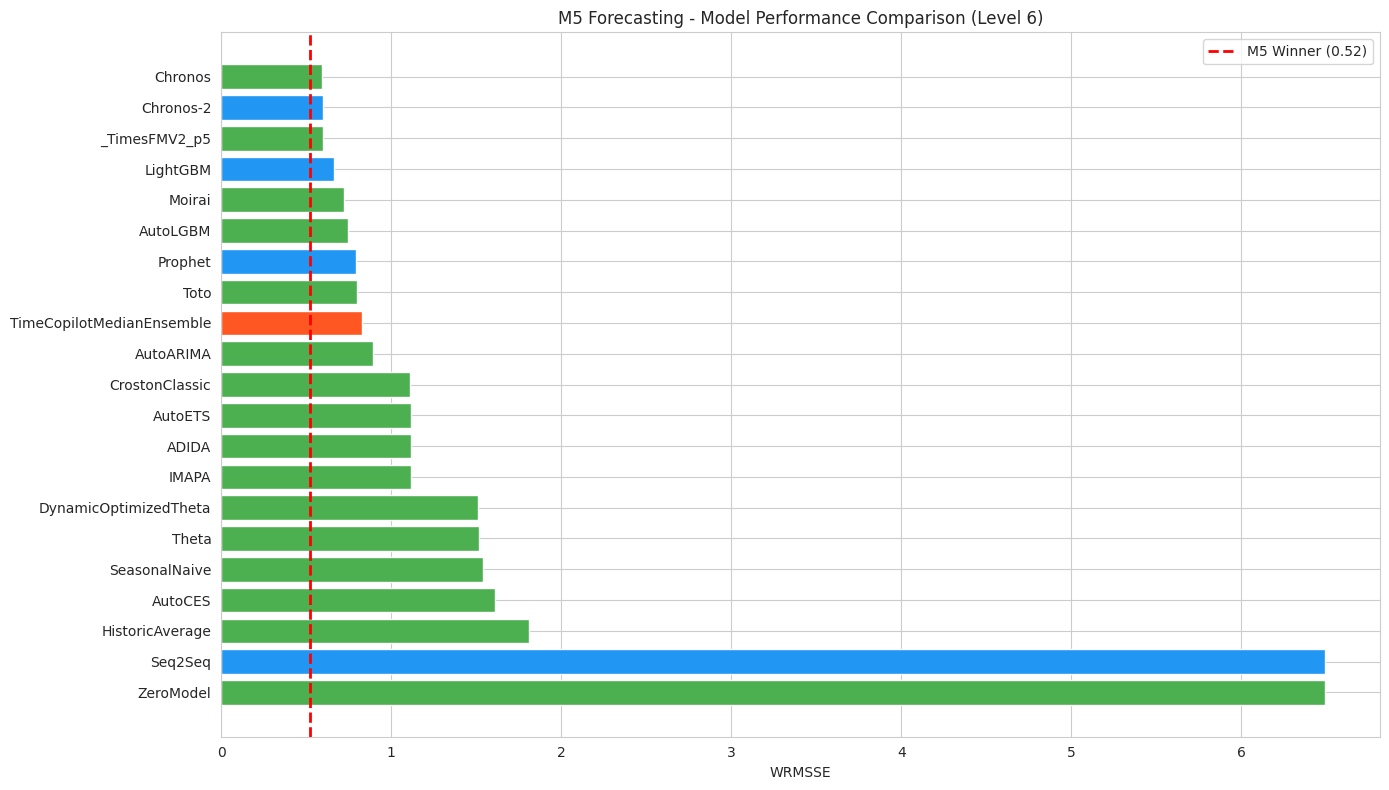

In [12]:
# メトリクス棒グラフ
fig, ax = plt.subplots(figsize=(14, 8))

# 色分け
colors = []
for model in summary_table["model"]:
    if model in BASELINE_MODELS:
        colors.append("#2196F3")  # Blue for baseline
    elif model == "TimeCopilotMedianEnsemble":
        colors.append("#FF5722")  # Orange for ensemble
    elif model in timecopilot_individual_models:
        colors.append("#4CAF50")  # Green for TimeCopilot models
    else:
        colors.append("#9E9E9E")  # Gray for others

bars = ax.barh(summary_table["model"], summary_table["metric"], color=colors)
ax.axvline(x=M5_WINNER_WRMSSE, color="red", linestyle="--", linewidth=2, label=f"M5 Winner ({M5_WINNER_WRMSSE})")
ax.set_xlabel(f"{METRIC_NAME.upper()}")
ax.set_title(f"M5 Forecasting - Model Performance Comparison (Level {AGGREGATION_LEVEL})")
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / "metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 時系列予測グラフ - TimeCopilotモデル全比較

In [13]:
def plot_forecast_comparison(
    unique_id: str,
    context_df: pd.DataFrame,
    actuals_df: pd.DataFrame,
    predictions: dict[str, pd.DataFrame],
    models_to_plot: list[str],
    metrics_df: pd.DataFrame,
    metric_name: str,
    title: str,
    save_path: Path | None = None,
) -> None:
    """予測結果を時系列グラフで比較"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # データ取得
    ctx = context_df[context_df["unique_id"] == unique_id].sort_values("ds")
    act = actuals_df[actuals_df["unique_id"] == unique_id].sort_values("ds")
    
    # カラーパレット
    colors = plt.cm.tab20(np.linspace(0, 1, len(models_to_plot)))
    
    # === Plot 1: 全体像（コンテキスト + 予測期間） ===
    ax1 = axes[0, 0]
    ax1.plot(ctx["ds"], ctx["y"], color="lightblue", linewidth=1, label="Context")
    ax1.plot(act["ds"], act["y"], color="green", linewidth=2, marker="o", markersize=3, label="Ground Truth")
    
    for i, model_name in enumerate(models_to_plot[:5]):  # 上位5モデルのみ
        if model_name in predictions:
            pred = predictions[model_name]
            pred_series = pred[pred["unique_id"] == unique_id].sort_values("ds")
            if not pred_series.empty:
                metric_val = metrics_df[metrics_df["model"] == model_name]["metric"].values
                metric_str = f" ({metric_name.upper()}={metric_val[0]:.4f})" if len(metric_val) > 0 else ""
                ax1.plot(
                    pred_series["ds"], pred_series["yhat"],
                    linestyle="--", color=colors[i], linewidth=1.5,
                    label=f"{model_name}{metric_str}"
                )
    
    ax1.axvline(x=act["ds"].min(), color="gray", linestyle=":", alpha=0.7)
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Sales (Aggregated)")
    ax1.set_title(f"Full View: Context + Forecast ({unique_id})")
    ax1.legend(loc="upper left", fontsize=8)
    ax1.tick_params(axis="x", rotation=45)
    
    # === Plot 2: 予測期間のズーム ===
    ax2 = axes[0, 1]
    ax2.plot(act["ds"], act["y"], color="green", linewidth=2, marker="o", markersize=4, label="Ground Truth")
    
    for i, model_name in enumerate(models_to_plot):
        if model_name in predictions:
            pred = predictions[model_name]
            pred_series = pred[pred["unique_id"] == unique_id].sort_values("ds")
            if not pred_series.empty:
                metric_val = metrics_df[metrics_df["model"] == model_name]["metric"].values
                metric_str = f" ({metric_val[0]:.4f})" if len(metric_val) > 0 else ""
                ax2.plot(
                    pred_series["ds"], pred_series["yhat"],
                    linestyle="--", marker=".", color=colors[i], linewidth=1.5,
                    label=f"{model_name}{metric_str}"
                )
    
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Sales (Aggregated)")
    ax2.set_title(f"Forecast Zoom ({unique_id})")
    ax2.legend(loc="upper right", fontsize=7, ncol=2)
    ax2.tick_params(axis="x", rotation=45)
    
    # === Plot 3: 予測誤差 ===
    ax3 = axes[1, 0]
    
    for i, model_name in enumerate(models_to_plot[:8]):  # 上位8モデル
        if model_name in predictions:
            pred = predictions[model_name]
            pred_series = pred[pred["unique_id"] == unique_id].sort_values("ds")
            if not pred_series.empty:
                merged = act.merge(pred_series, on=["unique_id", "ds"], how="inner")
                if not merged.empty:
                    error = np.abs(merged["yhat"] - merged["y"])
                    ax3.plot(
                        range(len(error)), error,
                        color=colors[i], linewidth=1.5, label=model_name
                    )
    
    ax3.set_xlabel("Prediction Step")
    ax3.set_ylabel("Absolute Error")
    ax3.set_title(f"Prediction Error ({unique_id})")
    ax3.legend(loc="upper right", fontsize=8)
    
    # === Plot 4: メトリクス比較バー ===
    ax4 = axes[1, 1]
    
    plot_metrics = metrics_df[metrics_df["model"].isin(models_to_plot)].copy()
    plot_metrics = plot_metrics.sort_values("metric")
    
    bar_colors = ["#4CAF50" if m in timecopilot_individual_models else "#2196F3" for m in plot_metrics["model"]]
    ax4.barh(plot_metrics["model"], plot_metrics["metric"], color=bar_colors)
    ax4.set_xlabel(f"{metric_name.upper()}")
    ax4.set_title(f"Model Performance - {metric_name.upper()}")
    ax4.invert_yaxis()
    
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    
    plt.show()

In [14]:
# 系列リスト（State × Category = 9系列）
all_series = actuals_df["unique_id"].unique().tolist()
print(f"All series ({len(all_series)}): {all_series}")

# 可視化用のサンプル系列
sample_series = all_series[:3]  # 最初の3系列
print(f"\nSample series for visualization: {sample_series}")

All series (9): ['CA_FOODS', 'CA_HOBBIES', 'CA_HOUSEHOLD', 'TX_FOODS', 'TX_HOBBIES', 'TX_HOUSEHOLD', 'WI_FOODS', 'WI_HOBBIES', 'WI_HOUSEHOLD']

Sample series for visualization: ['CA_FOODS', 'CA_HOBBIES', 'CA_HOUSEHOLD']


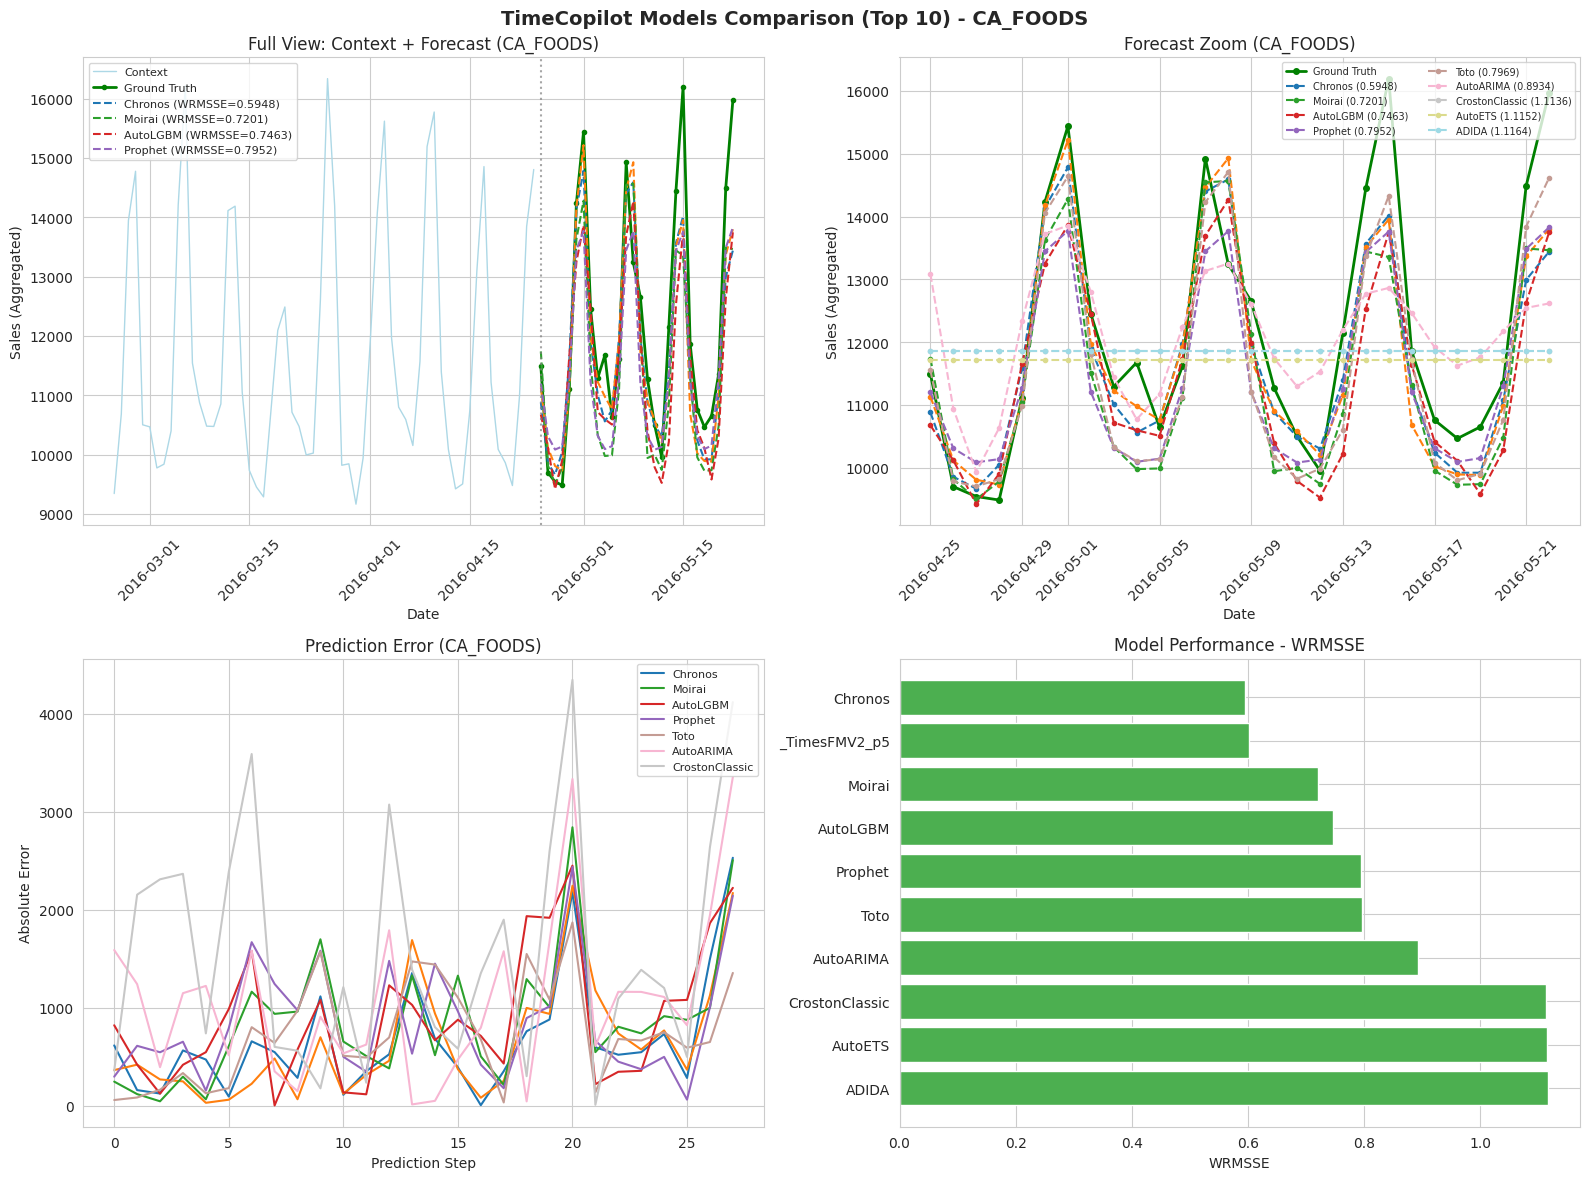

In [15]:
# TimeCopilotモデル全比較（1つの系列）
# 上位モデルのみプロット
tc_metrics = metrics_df[metrics_df["model"].isin(timecopilot_individual_models)].sort_values("metric")
top_tc_models = tc_metrics["model"].tolist()[:10]  # 上位10モデル

for series_id in sample_series[:1]:
    plot_forecast_comparison(
        unique_id=series_id,
        context_df=context_df,
        actuals_df=actuals_df,
        predictions=predictions,
        models_to_plot=top_tc_models,
        metrics_df=metrics_df,
        metric_name=METRIC_NAME,
        title=f"TimeCopilot Models Comparison (Top 10) - {series_id}",
        save_path=EXPERIMENT_DIR / f"timecopilot_models_comparison_{series_id.replace('_', '-')}.png",
    )

## 6. 時系列予測グラフ - TimeCopilotベスト vs ベースライン4種

In [16]:
# TimeCopilot内のベストモデルを特定
tc_metrics = metrics_df[metrics_df["model"].isin(timecopilot_individual_models)]
best_tc_model = tc_metrics.loc[tc_metrics["metric"].idxmin(), "model"]

print(f"Best TimeCopilot model: {best_tc_model}")
print(f"Best TimeCopilot {METRIC_NAME.upper()}: {tc_metrics['metric'].min():.4f}")

# 比較対象モデル
comparison_models = BASELINE_MODELS + [best_tc_model, "TimeCopilotMedianEnsemble"]
print(f"\nComparison models: {comparison_models}")

Best TimeCopilot model: Chronos
Best TimeCopilot WRMSSE: 0.5948

Comparison models: ['LightGBM', 'Prophet', 'Seq2Seq', 'Chronos-2', 'Chronos', 'TimeCopilotMedianEnsemble']


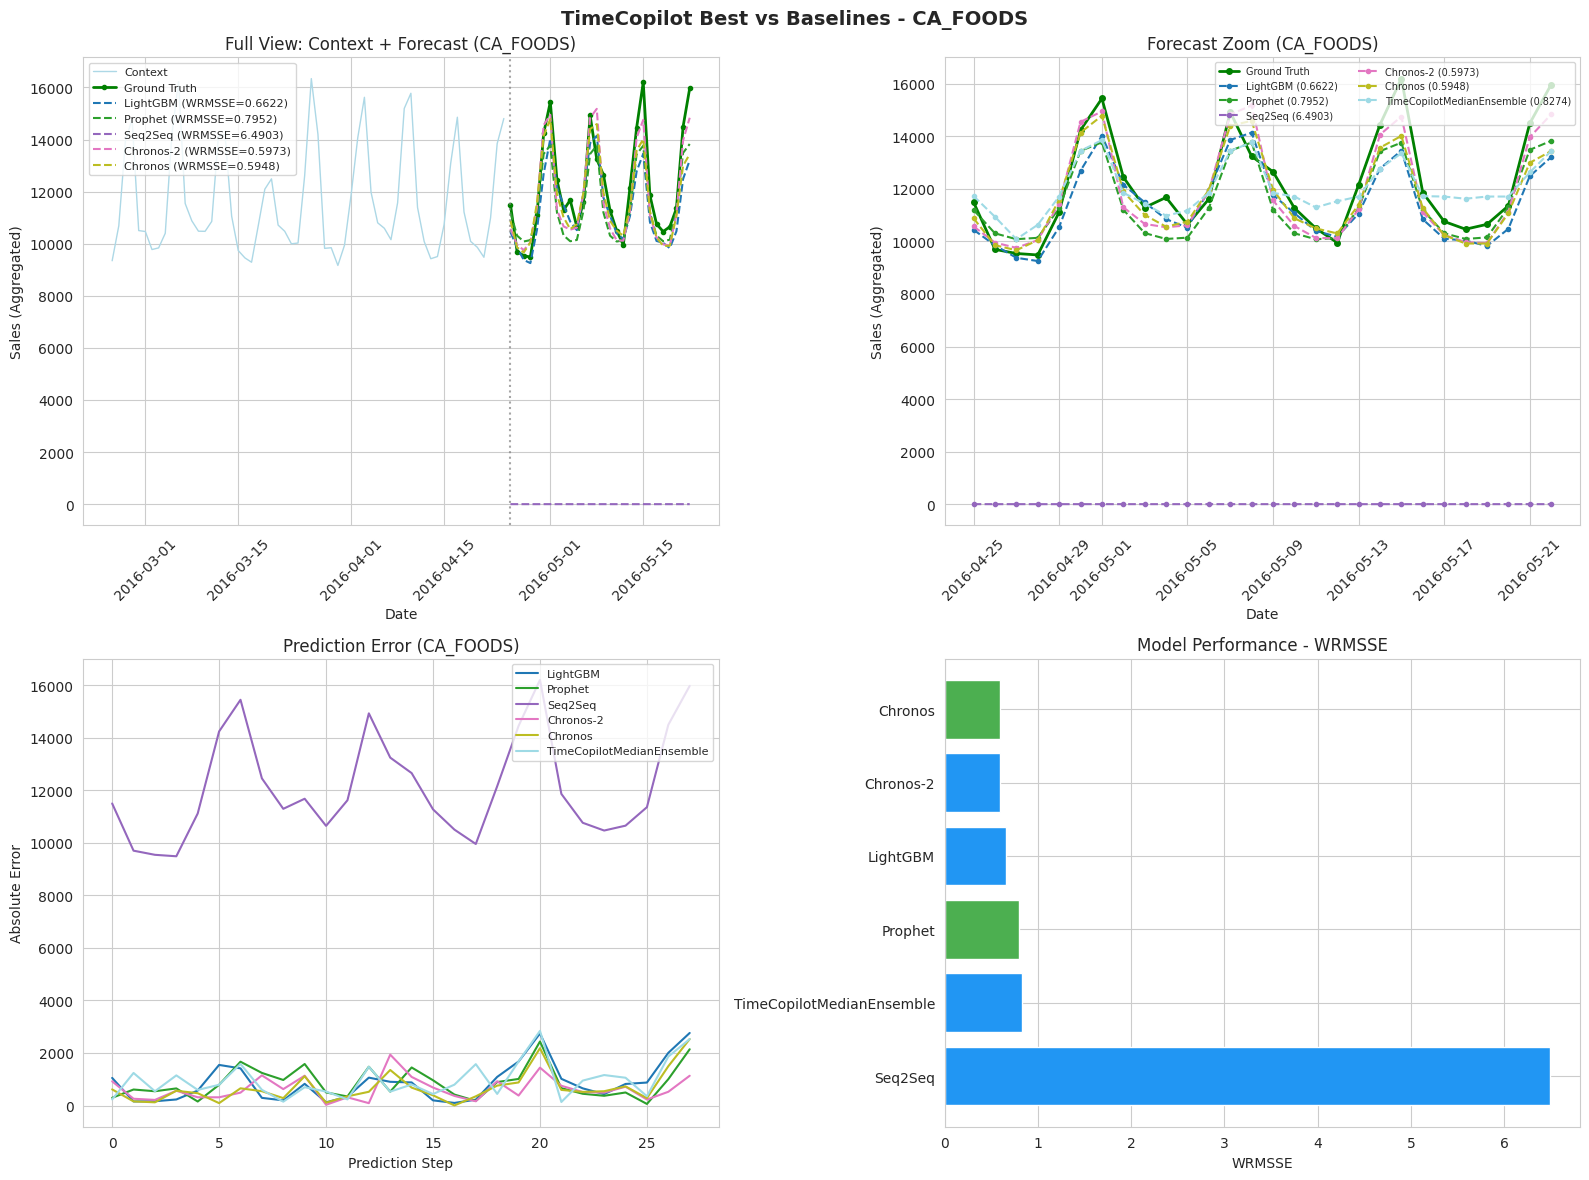

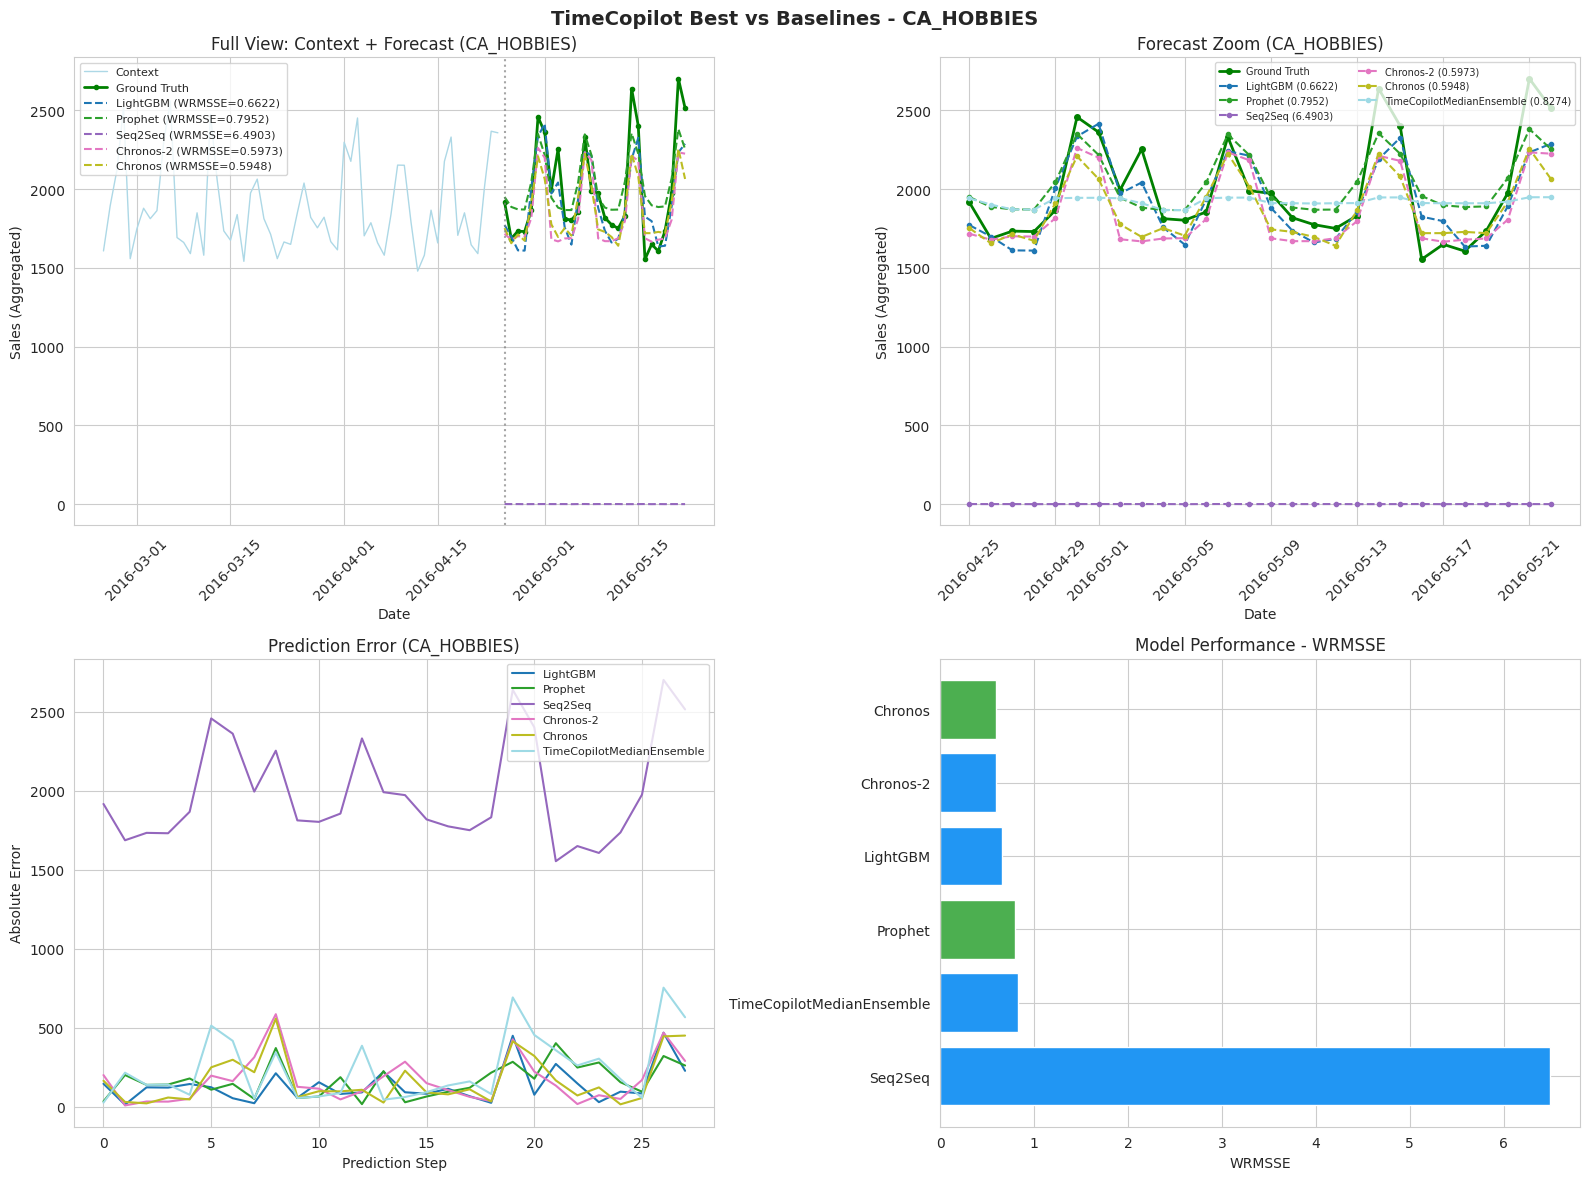

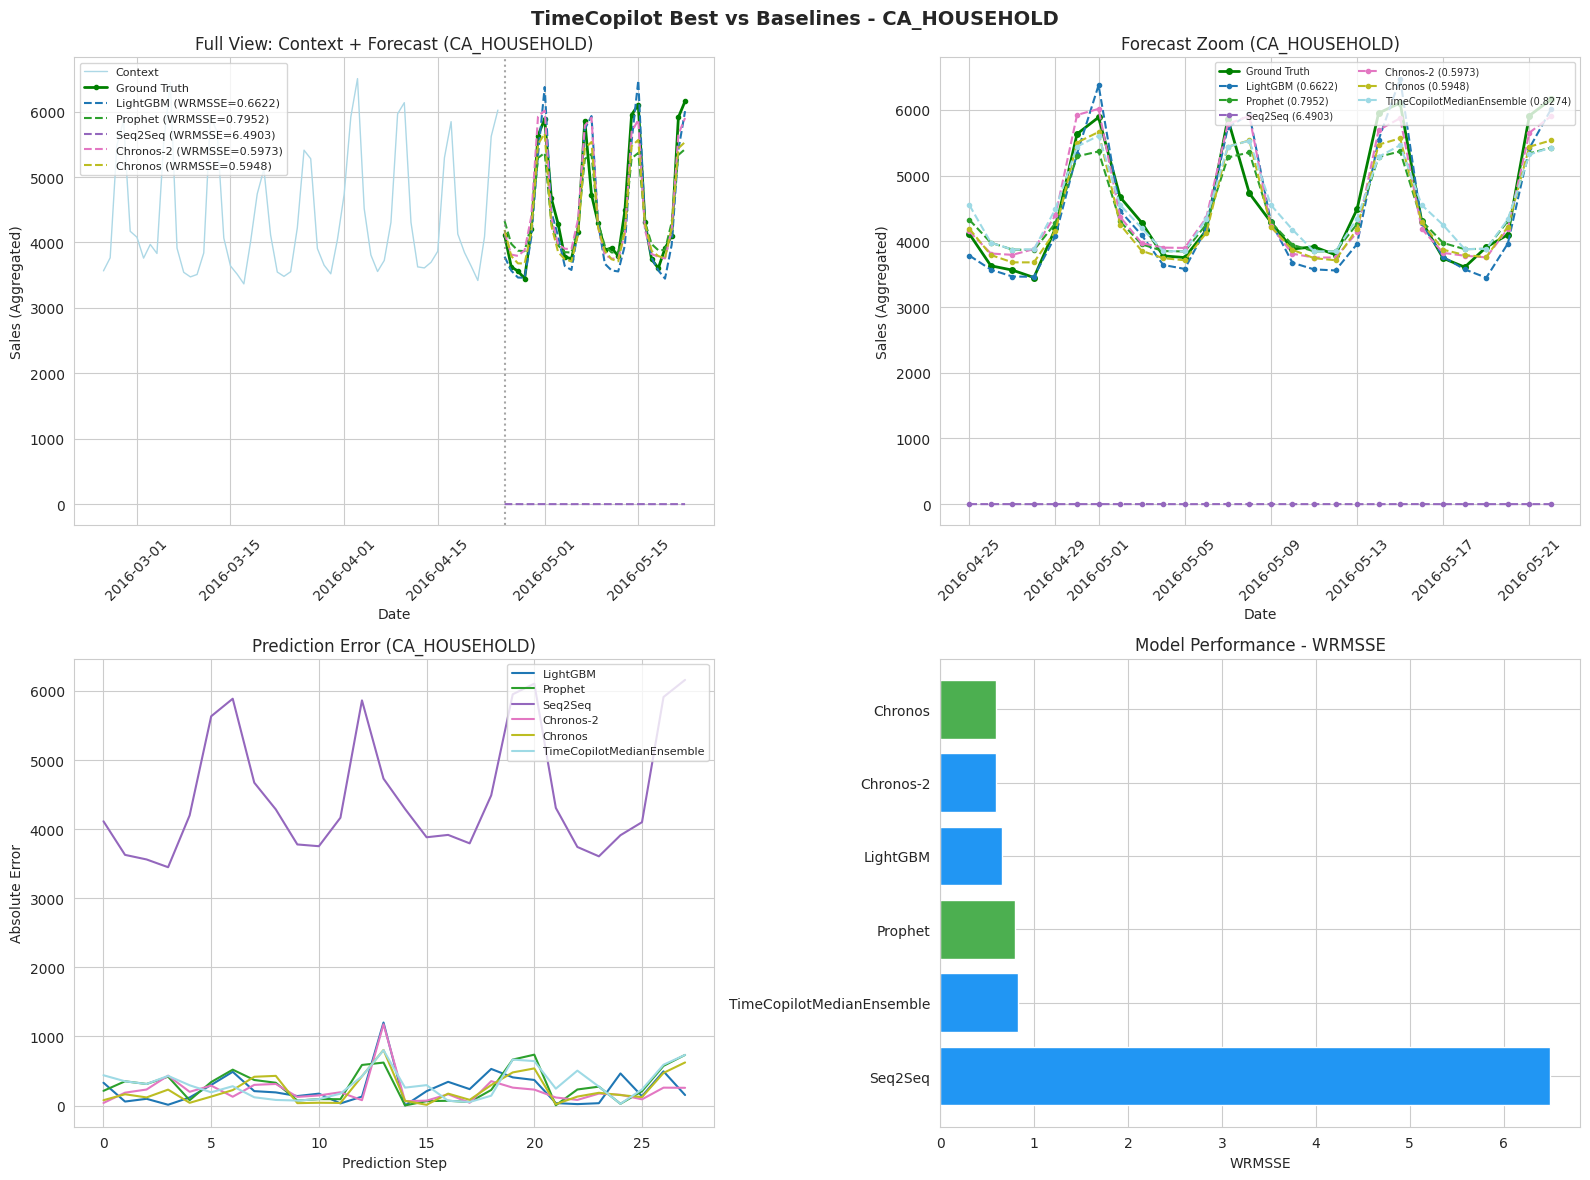

In [17]:
# ベースラインとTimeCopilotベストの比較
for series_id in sample_series:
    plot_forecast_comparison(
        unique_id=series_id,
        context_df=context_df,
        actuals_df=actuals_df,
        predictions=predictions,
        models_to_plot=comparison_models,
        metrics_df=metrics_df,
        metric_name=METRIC_NAME,
        title=f"TimeCopilot Best vs Baselines - {series_id}",
        save_path=EXPERIMENT_DIR / f"baseline_comparison_{series_id.replace('_', '-')}.png",
    )

## 7. 全系列のヒートマップ比較

In [18]:
def compute_series_rmse(
    actuals_df: pd.DataFrame,
    predictions: dict[str, pd.DataFrame],
    models: list[str],
) -> pd.DataFrame:
    """系列ごとのRMSEを計算"""
    results = []
    
    for model_name in models:
        if model_name not in predictions:
            continue
        pred = predictions[model_name]
        merged = actuals_df.merge(pred, on=["unique_id", "ds"], how="inner")
        
        for uid, group in merged.groupby("unique_id"):
            y_true = group["y"].values
            y_pred = group["yhat"].values
            
            # RMSE計算
            rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
            
            results.append({
                "model": model_name,
                "unique_id": uid,
                "rmse": rmse,
            })
    
    return pd.DataFrame(results)

# 系列ごとのメトリクス計算
series_metrics = compute_series_rmse(
    actuals_df=actuals_df,
    predictions=predictions,
    models=comparison_models,
)

print(f"Series metrics shape: {series_metrics.shape}")
series_metrics.head()

Series metrics shape: (54, 3)


,model,unique_id,rmse
0,LightGBM,CA_FOODS,1132.952111
1,LightGBM,CA_HOBBIES,173.988728
2,LightGBM,CA_HOUSEHOLD,346.701647
3,LightGBM,TX_FOODS,851.839566
4,LightGBM,TX_HOBBIES,140.926851


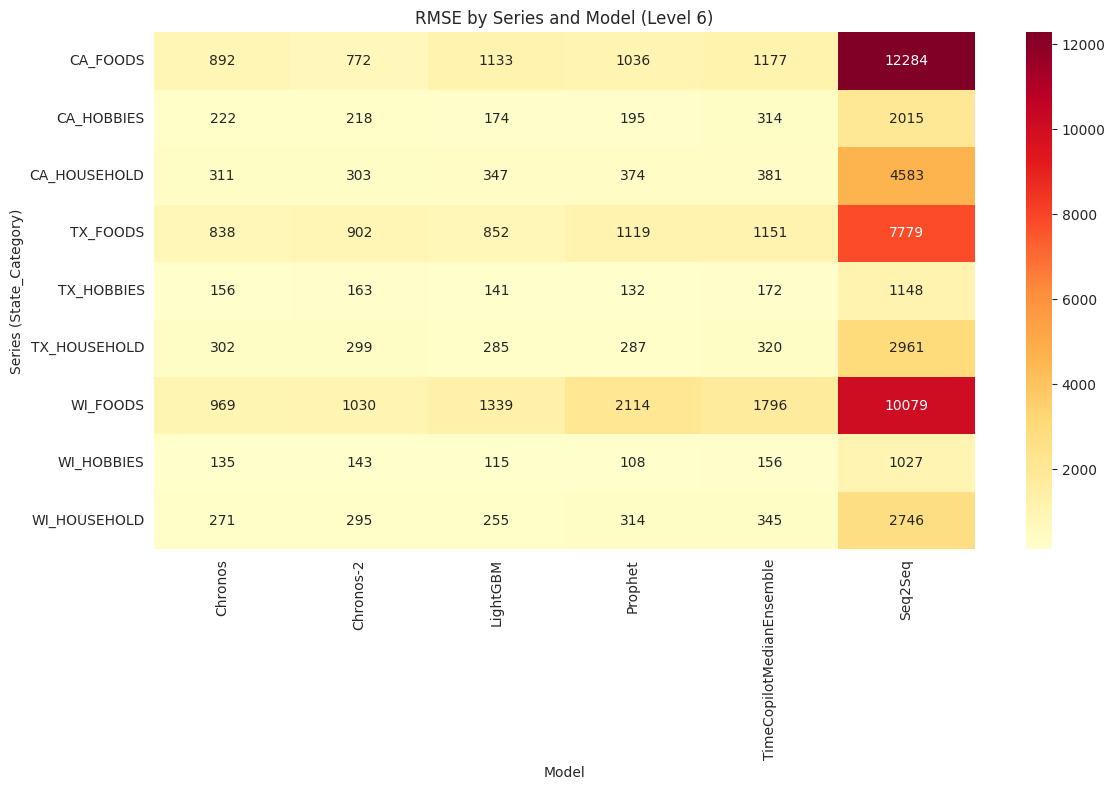

In [19]:
# ヒートマップ用にピボット
heatmap_df = series_metrics.pivot(index="unique_id", columns="model", values="rmse")

# モデル順序を指定（メトリクス順）
model_order = metrics_df[metrics_df["model"].isin(comparison_models)].sort_values("metric")["model"].tolist()
heatmap_df = heatmap_df[[m for m in model_order if m in heatmap_df.columns]]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
)
ax.set_title(f"RMSE by Series and Model (Level {AGGREGATION_LEVEL})")
ax.set_xlabel("Model")
ax.set_ylabel("Series (State_Category)")

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / "series_rmse_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 全9系列の予測比較グリッド

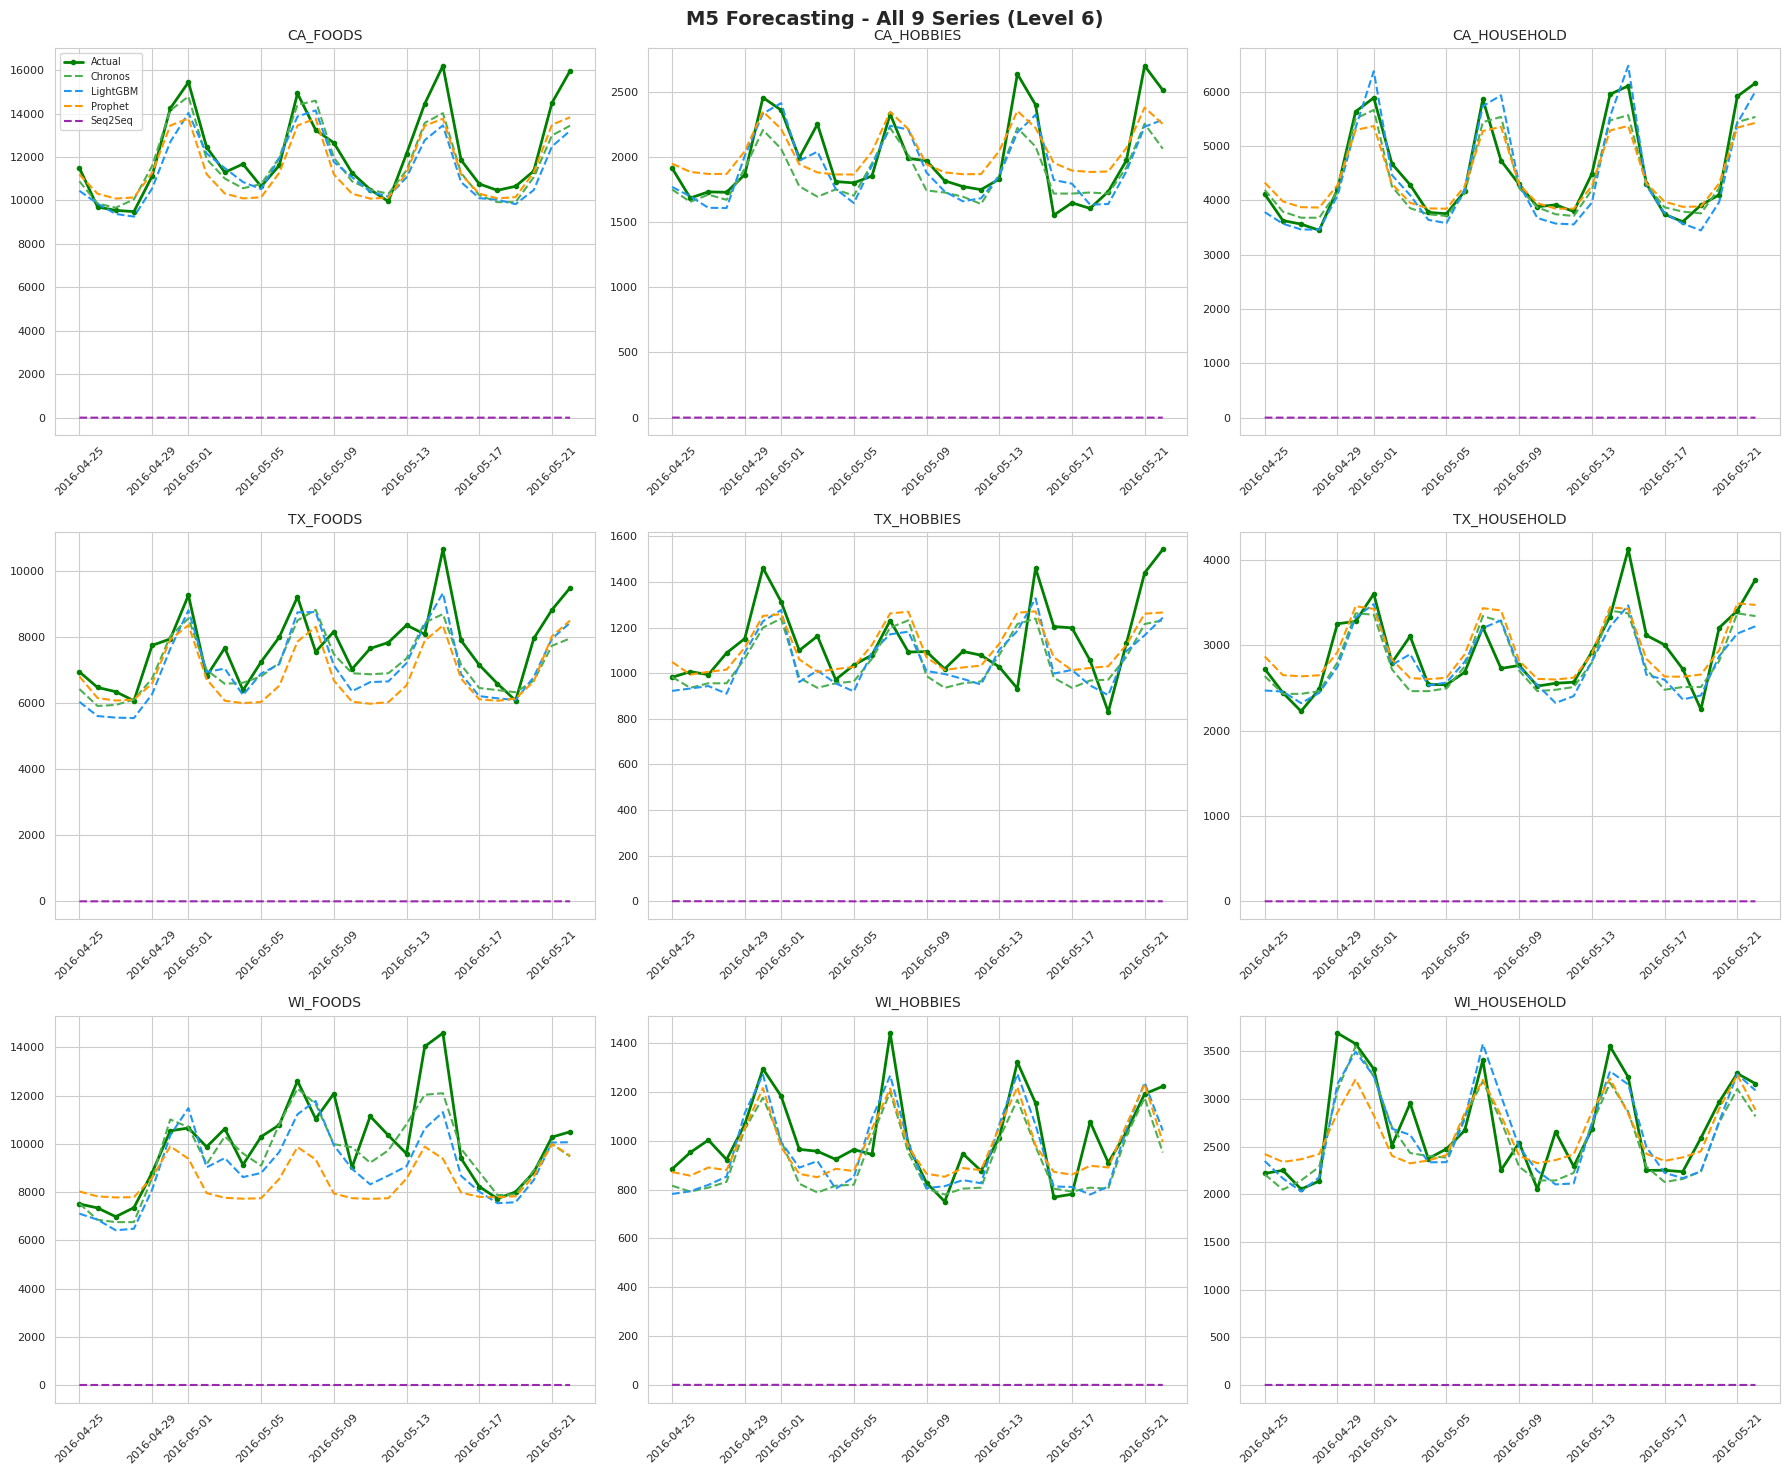

In [20]:
# 全9系列を3x3グリッドで表示
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# 上位3モデル + ベスト比較用
top_models = [best_tc_model] + BASELINE_MODELS[:3]
colors = ["#4CAF50", "#2196F3", "#FF9800", "#9C27B0"]

for idx, series_id in enumerate(all_series):
    ax = axes[idx]
    act = actuals_df[actuals_df["unique_id"] == series_id].sort_values("ds")
    
    # Ground Truth
    ax.plot(act["ds"], act["y"], color="green", linewidth=2, marker="o", markersize=3, label="Actual")
    
    # 各モデルの予測
    for i, model_name in enumerate(top_models):
        if model_name in predictions:
            pred = predictions[model_name]
            pred_series = pred[pred["unique_id"] == series_id].sort_values("ds")
            if not pred_series.empty:
                ax.plot(
                    pred_series["ds"], pred_series["yhat"],
                    linestyle="--", color=colors[i], linewidth=1.5,
                    label=model_name
                )
    
    ax.set_title(series_id, fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    if idx == 0:
        ax.legend(loc="upper left", fontsize=7)

plt.suptitle(f"M5 Forecasting - All 9 Series (Level {AGGREGATION_LEVEL})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / "all_series_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. サマリレポート

In [21]:
# サマリレポート生成
print("="*70)
print(f"M5 Forecasting - Experiment Summary (Level {AGGREGATION_LEVEL})")
print("="*70)
print(f"\nDataset: M5 Forecasting - Accuracy")
print(f"Aggregation Level: {AGGREGATION_LEVEL} (State × Category)")
print(f"Metric: {METRIC_NAME.upper()}")
print(f"Horizon: {HORIZON} days")
print(f"Number of series: {actuals_df['unique_id'].nunique()}")
print(f"\nM5 Winner Score (reference): {M5_WINNER_WRMSSE}")

print("\n" + "-"*70)
print("Top 5 Models:")
print("-"*70)
for i, row in metrics_df.head(5).iterrows():
    model_type = "(TimeCopilot)" if row["model"] in timecopilot_individual_models else "(Baseline)" if row["model"] in BASELINE_MODELS else ""
    print(f"  {i+1}. {row['model']:30s} {METRIC_NAME.upper()}: {row['metric']:.4f}  {model_type}")

print("\n" + "-"*70)
print("Baseline Models Performance:")
print("-"*70)
baseline_metrics = metrics_df[metrics_df["model"].isin(BASELINE_MODELS)].sort_values("metric")
for i, row in baseline_metrics.iterrows():
    print(f"  {row['model']:20s} {METRIC_NAME.upper()}: {row['metric']:.4f}")

print("\n" + "-"*70)
print("TimeCopilot Performance:")
print("-"*70)
print(f"  Best Model: {best_tc_model}")
print(f"  Best {METRIC_NAME.upper()}: {tc_metrics['metric'].min():.4f}")
ensemble_metric = metrics_df[metrics_df["model"] == "TimeCopilotMedianEnsemble"]["metric"].values
if len(ensemble_metric) > 0:
    print(f"  MedianEnsemble {METRIC_NAME.upper()}: {ensemble_metric[0]:.4f}")

print("\n" + "="*70)

M5 Forecasting - Experiment Summary (Level 6)

Dataset: M5 Forecasting - Accuracy
Aggregation Level: 6 (State × Category)
Metric: WRMSSE
Horizon: 28 days
Number of series: 9

M5 Winner Score (reference): 0.52

----------------------------------------------------------------------
Top 5 Models:
----------------------------------------------------------------------
  1. Chronos                        WRMSSE: 0.5948  (TimeCopilot)
  2. Chronos-2                      WRMSSE: 0.5973  (Baseline)
  3. _TimesFMV2_p5                  WRMSSE: 0.6017  (TimeCopilot)
  4. LightGBM                       WRMSSE: 0.6622  (Baseline)
  5. Moirai                         WRMSSE: 0.7201  (TimeCopilot)

----------------------------------------------------------------------
Baseline Models Performance:
----------------------------------------------------------------------
  Chronos-2            WRMSSE: 0.5973
  LightGBM             WRMSSE: 0.6622
  Prophet              WRMSSE: 0.7952
  Seq2Seq              W